# Lecture 7a — Three scorers, one corpus

**25882 AI-powered Investment and Risk Management**

---

### The question

> **If three sentiment models read the same 4,845 sentences, how often do they agree — and are the disagreements random?**

If the disagreements were random noise, you could average them away. If they are
systematic — if the models fail on the *same* sentences, in the *same* direction —
then no amount of ensembling saves you, and the choice of scorer is a real
modelling decision with consequences you can measure.

### What you will do

1. Establish the **baseline** any model must beat, before running a single model.
2. Score the corpus three ways: VADER, Loughran–McDonald, and (optionally) FinBERT.
3. Read the confusion matrices to find out *how* each one fails, not just how often.
4. Show that the same models produce very different "accuracy" depending on which
   slice of the corpus you evaluate on.
5. Look at the sentences everything gets wrong, and decide whether a better model
   would have helped.

### Running this notebook

| Environment | What to do |
| --- | --- |
| Google Colab | Run the setup cell; it installs what is missing |
| Local Anaconda | `pip install pysentiment2 vaderSentiment plotly` |
| UTS JupyterHub | As above. If the network is restricted the FinBERT section will skip itself and say so — everything else still runs |

`airm7.py` must sit in the same folder as this notebook.

In [13]:
# --- setup -------------------------------------------------------------
import sys, subprocess, warnings
warnings.filterwarnings("ignore")

for pkg, mod in [("pysentiment2", "pysentiment2"),
                 ("vaderSentiment", "vaderSentiment"),
                 ("plotly", "plotly")]:
    try:
        __import__(mod)
    except ImportError:
        print(f"installing {pkg} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import airm7

pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", 90)
print("ready")

ready


## 1. The corpus

The **Financial PhraseBank** (Malo et al., 2014) is 4,845 sentences drawn from
financial news, each labelled *negative*, *neutral* or *positive* by 16 annotators
with a background in finance.

The feature that makes it worth using here is not the sentences — it is the
**agreement column**. Each sentence records how much of the annotator panel agreed
on its label:

| `agreement` | Meaning |
| --- | --- |
| `100` | every annotator chose the same label |
| `75` | at least three quarters agreed |
| `66` | at least two thirds agreed |
| `50` | at least half agreed |

So `agreement` is an ordinal measure of **how obvious the sentence is**. Filtering is
cumulative: `df[df.agreement >= 75]` gives you every sentence that at least
three quarters of humans could agree on.

Hold on to that. It is the whole of Section 4.

In [14]:
pb = airm7.load_phrasebank(agreement=50)          # everything
print()
print(pb.head(3).to_string(index=False))
print()
print("Sentences by strictest tier reached:")
print(pb["agreement"].value_counts().sort_index(ascending=False).to_string())
print()
print("Label distribution:")
print((pb["label"].value_counts(normalize=True) * 100).round(1).to_string())

  PhraseBank: 4,838 sentences at agreement >= 50

                                                                                                                                                                                                                               sentence    label  agreement
                                                                                                                                                         ( A spokesperson told WWD to expect a 50-50 mix of clothing and home decor . )  neutral        100
( ADP News ) - Dec 11 , 2008 - Finnish construction and engineering company Outotec Oyj ( OMX : OTE1V ) said today it won a EUR 28 million ( USD 36.8 m ) order to expand the phosphate concentrator in Siilinjarvi of Norwegian minera positive        100
                      ( ADP News ) - Feb 11 , 2009 - Finnish management software solutions provider Ixonos Oyj ( HEL : XNS1V ) said today its net profit rose to EUR 3.5 million ( USD 4.5 m ) for

## 2. Benchmark first

Before running any model, write down the number it has to beat.

The corpus is dominated by *neutral* sentences. A model that reads nothing and
predicts "neutral" every single time already scores the neutral share. That is your
floor. Any model that cannot clear it has learned nothing, however sophisticated it is.

> **Habit to build:** the first number in any evaluation is the trivial baseline. If
> you compute it *after* you see your model's accuracy, you will unconsciously accept
> a worse benchmark.

In [15]:
cls, base = airm7.majority_baseline(pb["label"])
print(f"Majority-class baseline: always predict '{cls}'  ->  accuracy = {base:.3f}")

Majority-class baseline: always predict 'neutral'  ->  accuracy = 0.593


## 3. Rung 0 — VADER, the deliberately wrong instrument

VADER was tuned on social media posts and product reviews. It knows that "great!!!"
is enthusiastic and that "not bad" is mildly positive. It knows nothing whatsoever
about finance.

We run it not because anyone would ship it, but because **an instrument that is wrong
in a known way is the cheapest diagnostic you have**. If a finance-specific tool
cannot beat a general-purpose one on financial text, that tells you something is
broken in your pipeline, not in the literature.

In [16]:
vader = airm7.score_vader(pb["sentence"])
acc_vader = airm7.accuracy(pb["label"], vader["pred"])
print(f"VADER accuracy: {acc_vader:.3f}   (baseline {base:.3f})")

VADER accuracy: 0.544   (baseline 0.593)


## 4. Rung 1 — Loughran–McDonald

Loughran and McDonald (2011) showed that general-purpose psychology dictionaries
misclassify financial English, and built finance-specific word lists to fix it. The
words *liability*, *cost*, *tax* and *capital* are negative in a general dictionary
and neutral in a 10-K.

<details>
<summary><b>The maths (click to expand)</b></summary>

The score is a normalised count. For a document $d$ with $n^{+}_d$ words on the
positive list and $n^{-}_d$ on the negative list:

$$\text{tone}_d \;=\; \frac{n^{+}_d - n^{-}_d}{n^{+}_d + n^{-}_d} \;\in\; [-1, 1]$$

with $\text{tone}_d = 0$ by convention when the denominator is zero. We then band it
into three classes with a threshold $\tau$:

$$\widehat{y}_d = \begin{cases}
\text{positive} & \text{tone}_d > \tau \\
\text{negative} & \text{tone}_d < -\tau \\
\text{neutral} & \text{otherwise}
\end{cases}$$

Two things are worth noticing before you run it. The score depends only on *counts*,
so word order is irrelevant — "profit up, losses down" and "profit down, losses up"
are identical to it. And the denominator is the number of *sentiment* words, not the
number of words, so a sentence with one hit gets a score of exactly $\pm 1$.

</details>

The dictionary ships inside `pysentiment2`, so there is nothing to download.

Loughran-McDonald accuracy: 0.574   (baseline 0.593)


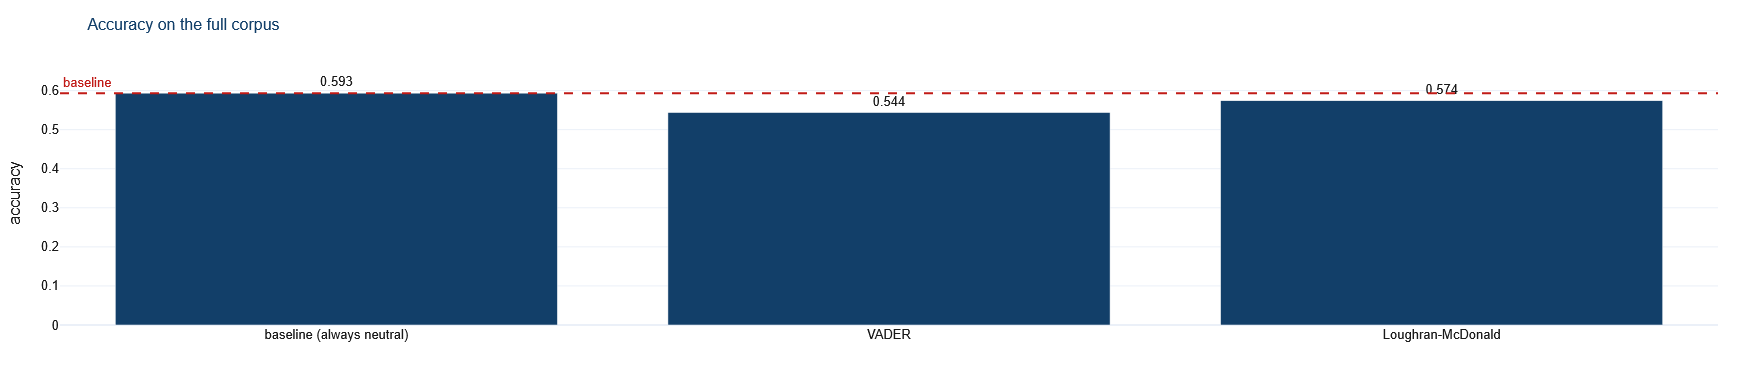

In [17]:
lm = airm7.score_lm(pb["sentence"])
acc_lm = airm7.accuracy(pb["label"], lm["pred"])
print(f"Loughran-McDonald accuracy: {acc_lm:.3f}   (baseline {base:.3f})")

fig = airm7.plot_bars(
    ["baseline\n(always neutral)", "VADER", "Loughran-McDonald"],
    [base, acc_vader, acc_lm],
    title="Accuracy on the full corpus", ylab="accuracy",
    ref=base, ref_label="baseline",
)
fig.show()

### 4a. Three sentences a dictionary cannot read

The failure mode is not subtle once you go looking for it. Predict, before you run
the cell, what each of these *should* be scored as — then look at what the dictionary
actually returns.

In [18]:
probes = [
    "Losses were not material and the liability was reduced",
    "We failed to lose market share this quarter",
    "The company's bearish positioning turned out to be a mistake",
    "Operating profit rose to EUR 12.3 mn from EUR 8.1 mn",
]
out = airm7.score_lm(probes)
out.insert(0, "sentence", probes)
print(out[["sentence", "polarity", "pred"]].to_string(index=False))

                                                    sentence  polarity     pred
      Losses were not material and the liability was reduced -0.999999 negative
                 We failed to lose market share this quarter -1.000000 negative
The company's bearish positioning turned out to be a mistake  0.000000  neutral
        Operating profit rose to EUR 12.3 mn from EUR 8.1 mn  0.999999 positive


A count cannot see negation, cannot see scope, and cannot see that "failed to lose"
is a good outcome. Notice also how many of these land on **exactly** $-1.0$: that is
the one-sentiment-word case, and it is the same mechanical polarisation you saw in
the lecture in the Buzz contour plot. Sparse input, extreme score.

This matters beyond dictionaries. Any scorer whose denominator is a count of matched
items will do this, and it will do it hardest on the thinnest data.

## 5. How each scorer fails

Accuracy is one number and it hides the interesting part. The confusion matrix shows
you *which* class each model reaches for when it is wrong.

Read the rows: each row is a human label, and the row shows where those sentences
were sent. A well-behaved model has mass on the diagonal. A model with a systematic
bias has mass in one off-diagonal cell.

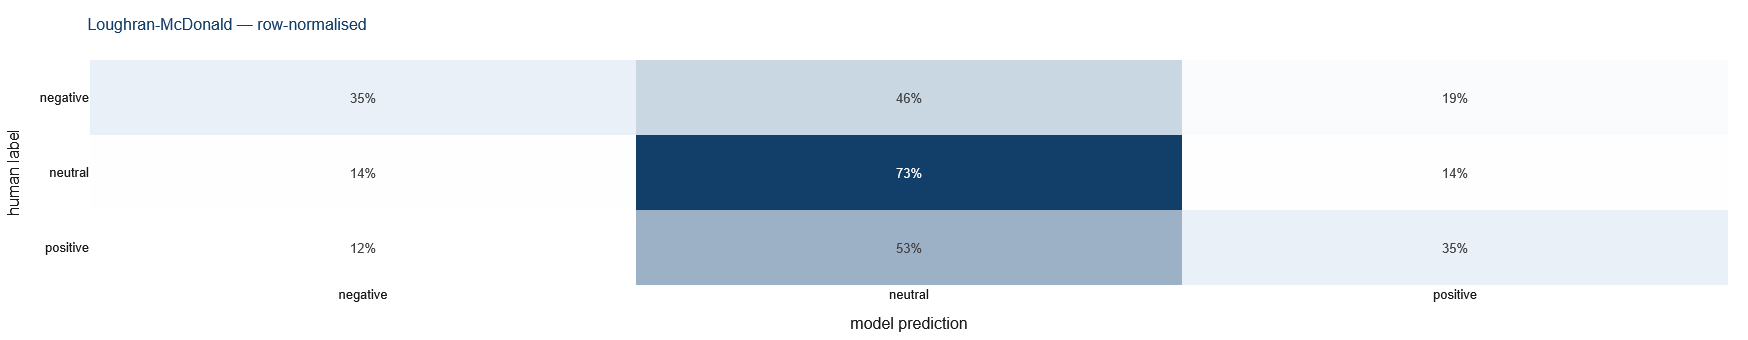

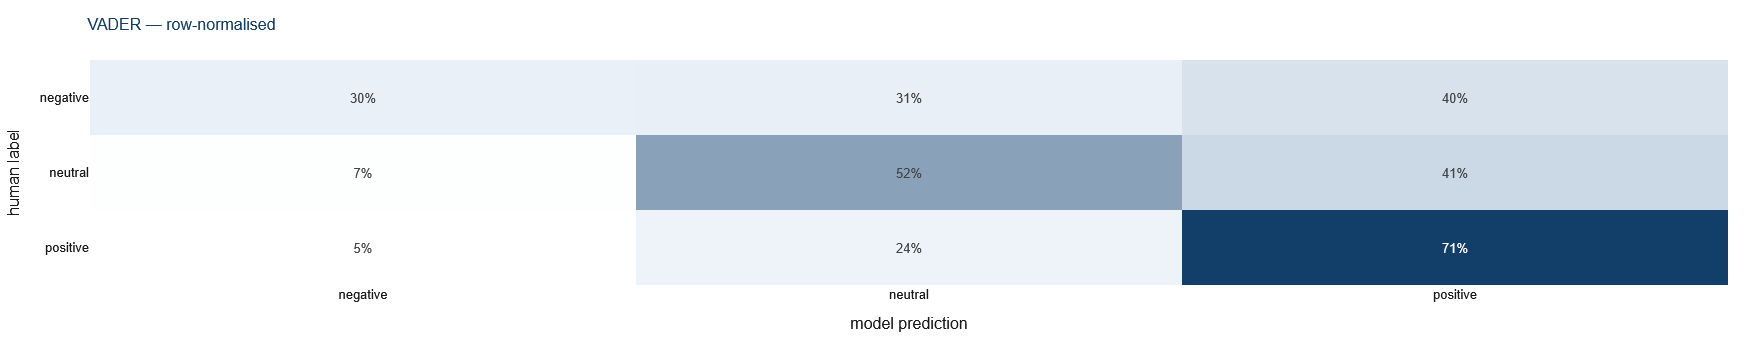

Share of each model's predictions that are 'neutral':
  human labels       0.593
  Loughran-McDonald  0.636
  VADER              0.414


In [19]:
cm_lm = airm7.confusion_frame(pb["label"], lm["pred"], normalize="row")
cm_vd = airm7.confusion_frame(pb["label"], vader["pred"], normalize="row")

airm7.plot_confusion(cm_lm, "Loughran-McDonald — row-normalised").show()
airm7.plot_confusion(cm_vd, "VADER — row-normalised").show()

print("Share of each model's predictions that are 'neutral':")
print(f"  human labels       {(pb['label']=='neutral').mean():.3f}")
print(f"  Loughran-McDonald  {(lm['pred']=='neutral').mean():.3f}")
print(f"  VADER              {(vader['pred']=='neutral').mean():.3f}")

**Look at the neutral row and the neutral prediction share before reading on.**

Two questions to answer from what you see:

1. When the dictionary is wrong about a *neutral* sentence, which way does it err?
   What does that tell you about the word lists?
2. Does either model predict "neutral" at roughly the rate humans do? A model that
   under-predicts neutral is manufacturing signal out of noise — which, in a trading
   context, means turnover you pay for and information you do not have.

## 6. The same models, two different accuracies

Now the point of the agreement column.

We hold the models completely fixed and change only the slice of the corpus we
evaluate on: first the sentences all 16 annotators agreed about, then progressively
more contentious ones.

Nothing about the models changes. Their measured accuracy will.

 agreement >=    n  baseline  VADER    LM
          100 2259     0.614  0.572 0.603
           75 3448     0.621  0.564 0.596
           66 4211     0.601  0.557 0.582
           50 4838     0.593  0.544 0.574


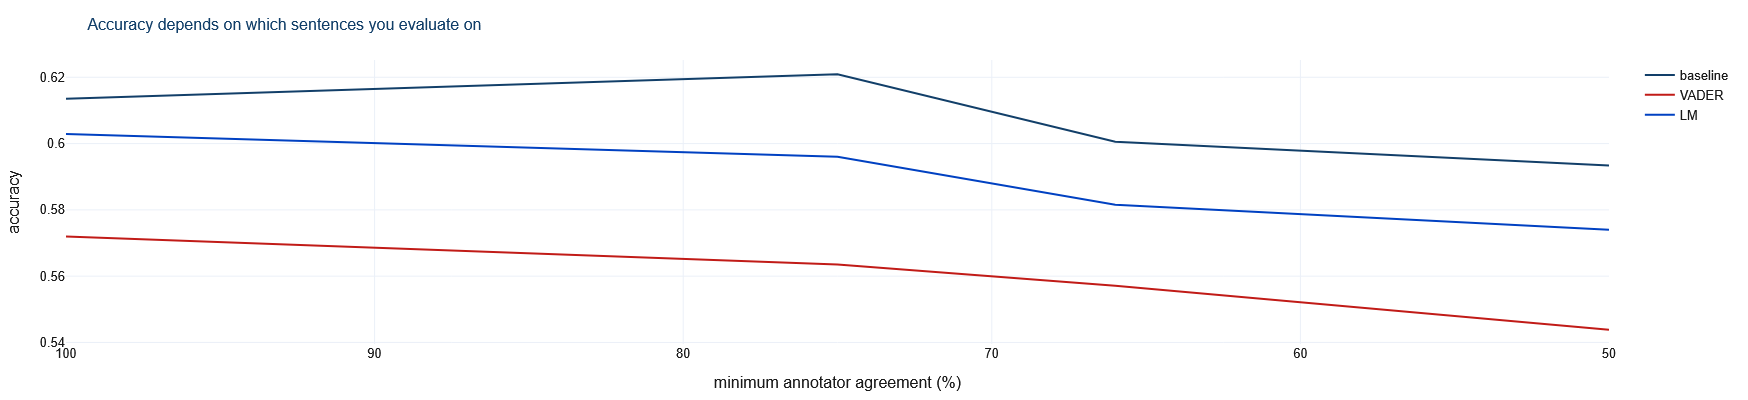

In [20]:
rows = []
for tier in (100, 75, 66, 50):
    sub = pb[pb["agreement"] >= tier]
    _, b = airm7.majority_baseline(sub["label"])
    rows.append({
        "agreement >=": tier,
        "n": len(sub),
        "baseline": b,
        "VADER": airm7.accuracy(sub["label"], vader.loc[sub.index, "pred"]),
        "LM": airm7.accuracy(sub["label"], lm.loc[sub.index, "pred"]),
    })
tiers = pd.DataFrame(rows)
print(tiers.round(3).to_string(index=False))

fig = airm7.plot_lines(tiers, "agreement >=", ["baseline", "VADER", "LM"],
                       title="Accuracy depends on which sentences you evaluate on",
                       xlab="minimum annotator agreement (%)", ylab="accuracy")
fig.update_xaxes(autorange="reversed")
fig.show()

### What this means for every accuracy figure you will ever read

You have just produced several different, equally honest "accuracy" numbers for the
same model. A paper reporting only the highest one is not lying; it has simply chosen
an evaluation set, and the choice was consequential.

This is the §2 slide made concrete. When you read that model A scores 0.85 and model
B scores 0.71, the first question is not "which is better" but **"on what, and does
that resemble the decision I am going to make?"**

Two very different targets get called "accuracy" in this literature:

| Target | What it measures | When it is the right target |
| --- | --- | --- |
| Label agreement | does the model match a human annotator? | you are automating a human reading task |
| Return direction | does the score predict what the price did? | you are trading it |

A model can be excellent at one and useless at the other. Kirtac and Germano (2024)
score 965,375 articles against **return direction** and find the Loughran–McDonald
dictionary at 0.501 — a coin toss — while transformer models reach 0.72–0.74. On
*this* notebook's label-agreement task the dictionary does considerably better than a
coin toss. Both results are correct. They are answers to different questions.

## 7. Stretch — the third rung

FinBERT (Araci, 2019) is BERT further trained on financial text and then fine-tuned
for sentiment. It reads a whole sentence, so negation and scope are within reach.

This section downloads roughly 440 MB of model weights. **If your network blocks it,
the cell will say so and skip** — nothing below depends on it.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

FinBERT accuracy: 0.890   (LM 0.574, baseline 0.593)


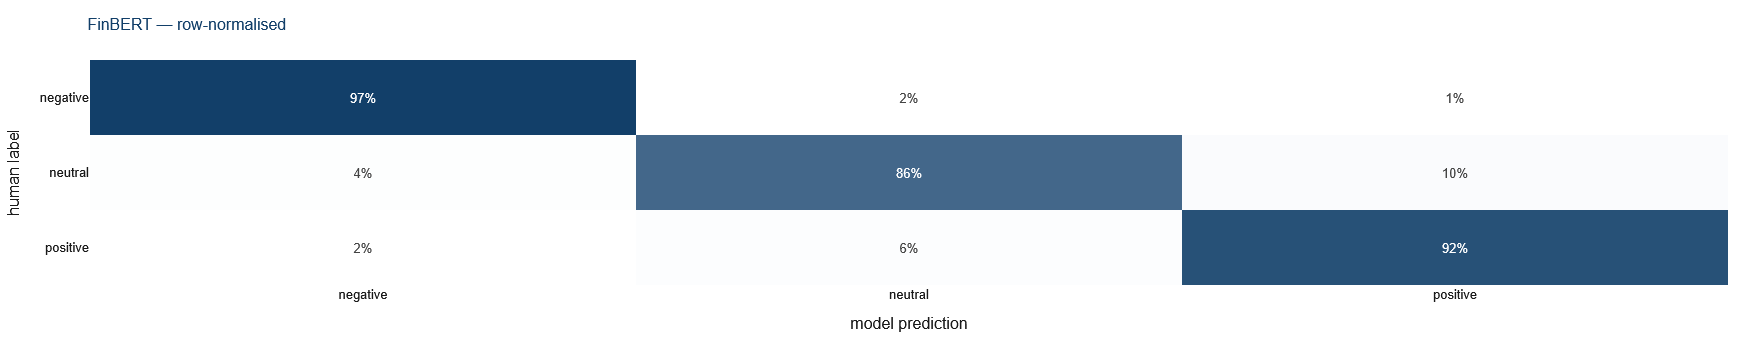


Does it fix the four probe sentences?


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

                                                    sentence  FinBERT       LM
      Losses were not material and the liability was reduced  neutral negative
                 We failed to lose market share this quarter negative negative
The company's bearish positioning turned out to be a mistake negative  neutral
        Operating profit rose to EUR 12.3 mn from EUR 8.1 mn positive positive


In [21]:
fin = airm7.score_finbert(pb["sentence"].tolist())

if fin is not None:
    acc_fin = airm7.accuracy(pb["label"], fin["pred"])
    print(f"FinBERT accuracy: {acc_fin:.3f}   (LM {acc_lm:.3f}, baseline {base:.3f})")
    airm7.plot_confusion(
        airm7.confusion_frame(pb["label"], fin["pred"], normalize="row"),
        "FinBERT — row-normalised").show()
    print("\nDoes it fix the four probe sentences?")
    fp = airm7.score_finbert(probes)
    if fp is not None:
        print(pd.DataFrame({"sentence": probes, "FinBERT": fp["pred"],
                            "LM": airm7.score_lm(probes)["pred"]}).to_string(index=False))
else:
    print("\nSkipped. Sections 8 and 9 run on VADER and LM alone.")

## 8. Are the disagreements random?

Now the question the notebook opened with.

If two scorers disagree at random, the sentences they fight over should look like any
other sentences. If they disagree *systematically*, the contested sentences should be
special in some measurable way — and the obvious candidate is that they are the ones
**humans** also found hard.

In [ ]:
work = pb.copy()
work["lm"] = lm["pred"].values
work["vader"] = vader["pred"].values
if fin is not None:
    work["finbert"] = fin["pred"].values

scorers = [c for c in ["lm", "vader", "finbert"] if c in work.columns]

In [23]:
work

,sentence,label,agreement,lm,vader,finbert,n_correct,all_wrong
0,( A spokesperson told WWD to expect a 50-50 mix of clothing and home decor . ),neutral,100,neutral,neutral,neutral,3,False
1,"( ADP News ) - Dec 11 , 2008 - Finnish construction and engineering company Outotec Oy...",positive,100,positive,positive,positive,3,False
2,"( ADP News ) - Feb 11 , 2009 - Finnish management software solutions provider Ixonos O...",positive,100,positive,positive,positive,3,False
3,"( ADP News ) - Feb 11 , 2009 - Finnish wood products technology supplier Raute Oyj ( H...",negative,100,positive,positive,negative,1,False
4,"( ADP News ) - Feb 12 , 2009 - Finnish IT solutions provider Affecto Oyj ( HEL : AFE1V...",positive,100,positive,positive,positive,3,False
...,...,...,...,...,...,...,...,...
4833,hybrid bond 18 January 2010 - Finnish IT consultancy Trainers ' House Oyj HEL : TRH1V ...,neutral,50,positive,positive,positive,0,True
4834,"is planning to expand its product portfolio in the harbor segment , chief executive Pe...",positive,50,neutral,positive,positive,2,False
4835,"pct lower at 4,442.10 .",neutral,50,neutral,negative,negative,1,False
4836,s already good position in the technical building services market in Ostrobothnia .,neutral,50,positive,positive,positive,0,True


In [27]:
# pairwise agreement between scorers (not with the human label)
print("Pairwise agreement between scorers:")
for i, a in enumerate(scorers):
    for b in scorers[i + 1:]:
        print(f"  {a:8s} vs {b:8s}: {(work[a] == work[b]).mean():.3f}")

work["n_correct"] = sum((work[s] == work["label"]).astype(int) for s in scorers)
work["all_wrong"] = work["n_correct"] == 0

# tab = (work.groupby("agreement")["all_wrong"].agg(["mean", "size"])
#            .rename(columns={"mean": "share_all_scorers_wrong", "size": "n"})
#            .sort_index(ascending=False))
tab = (work.groupby("agreement")["all_wrong"].agg(["size", "mean"])
           .rename(columns={"size": "no of sentences", "mean": "share_all_scorers_wrong"})
           .sort_index(ascending=False))
print("\nAre the sentences every scorer misses the ones humans argued about?")
print(tab.round(3).to_string())

Pairwise agreement between scorers:
  lm       vs vader   : 0.535
  lm       vs finbert : 0.551
  vader    vs finbert : 0.556

Are the sentences every scorer misses the ones humans argued about?
           no of sentences  share_all_scorers_wrong
agreement                                          
100                   2259                    0.008
75                    1189                    0.021
66                     763                    0.066
50                     627                    0.097


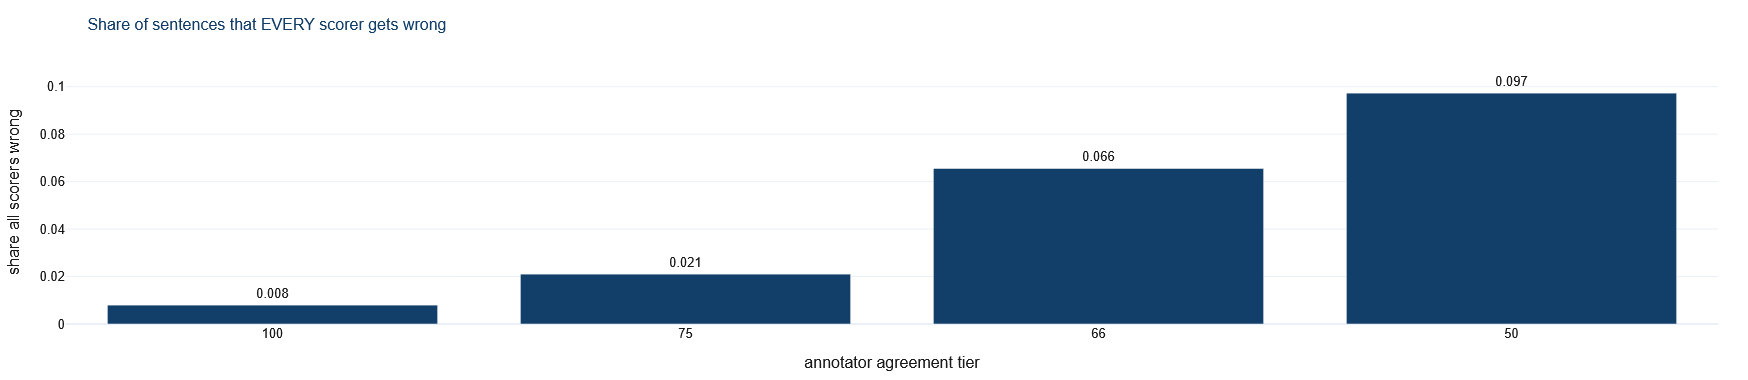

In [29]:
fig = airm7.plot_bars(
    [str(i) for i in tab.index],
    tab["share_all_scorers_wrong"].tolist(),
    title="Share of sentences that EVERY scorer gets wrong",
    xlab="annotator agreement tier", ylab="share all scorers wrong",
    text_fmt="{:.3f}",
)
fig.show()

If the bars rise as annotator agreement falls, the models and the humans are finding
the *same* sentences hard. That is not a comforting result dressed up — it has a
concrete implication:

> **Ensembling will not rescue you here.** Averaging three models that fail on the
> same inputs gives you a fourth model that fails on those inputs, with a smoother
> error distribution and the same blind spot.

The productive response is not a better classifier. It is to accept that a fraction
of your corpus is genuinely ambiguous, measure how large that fraction is, and carry
it forward as a stated uncertainty rather than hiding it inside an accuracy figure.

In [34]:
# Read some. This is the most useful cell in the notebook.
# head(5) - top 5 sentences - change to 15
# ['sentence'][:80] - print frist 80 characters from a sentence - change to 280

hard = work[work["all_wrong"]].sort_values("agreement")
print(f"{len(hard):,} sentences that every scorer gets wrong. A sample:\n")
for _, r in hard.head(5).iterrows():
    preds = " | ".join(f"{s}={r[s]}" for s in scorers)
    print(f"  human={r['label']:<9s} agreement={r['agreement']:<4} {preds}")
    print(f"    \"{r['sentence'][:80]}\"\n")

154 sentences that every scorer gets wrong. A sample:

  human=negative  agreement=50   lm=neutral | vader=positive | finbert=neutral
    "A tinyurl link takes users to a scamming site promising that users can earn thou"

  human=neutral   agreement=50   lm=positive | vader=positive | finbert=positive
    "According to preliminary information by the Finnish Forest Industries Federation"

  human=neutral   agreement=50   lm=negative | vader=negative | finbert=negative
    "According to product manager Lassi Hietanen , building a power plant that burns "

  human=neutral   agreement=50   lm=negative | vader=negative | finbert=negative
    "Another problem is cola-flavoured long drinks ."

  human=neutral   agreement=50   lm=positive | vader=positive | finbert=positive
    "As previously announced , GeoSentric Oyj entered into financing agreements with "



## 9. Exercises

### Core

1. **Move the threshold.** `score_lm` takes a `band` argument (default `0.10`).
   Re-score at `band = 0.0`, `0.25` and `0.5`. Plot accuracy against the band. Where
   is the maximum, and how much accuracy is a purely arbitrary threshold worth?
2. **Fix the class imbalance.** Overall accuracy rewards predicting the majority
   class. Compute per-class recall for LM instead. Does your ranking of the scorers
   survive?
3. **Sentence length.** Add a `n_words` column. Are the errors concentrated in short
   sentences? Give the mechanism, not just the correlation.

### Stretch

4. **Build a better dictionary baseline.** Take the LM word lists from
   `pysentiment2` and add negation handling: flip the polarity of any sentiment word
   within three tokens after *not*, *no*, *failed to*, *without*. How much of the
   gap to FinBERT does that close? This is worth doing before concluding that you
   need a transformer.
5. **Bootstrap the difference.** Resample the corpus 1,000 times and produce a
   confidence interval for `acc_lm - acc_vader`. Is the gap you have been discussing
   actually distinguishable from zero?
6. **The neutral band is a decision, not a fact.** For a trading application you may
   only care about strongly-signed sentences. Keep only the top and bottom deciles of
   `lm["polarity"]` and re-measure. What happens to accuracy, and what have you given
   up to get it?

---

## Carry forward to Lec07b

You now have a scorer and a sense of how much to trust it. The next notebook asks a
different question entirely: **suppose your scorer is perfect — is the coefficient you
estimate from it real?**

The answer turns on something that has nothing to do with NLP.